# Taller: Detección de Anomalías en ECG con Autoencoder 1D (MIT-BIH)

Objetivo general:
Entrenar un modelo autoencoder 1D utilizando latidos normales de señales ECG, para luego detectar anomalías a partir del error de reconstrucción.

Flujo de trabajo:

1. Carga y segmentación de los latidos a partir del registro.
2. Visualización de ejemplos de señal y anotaciones.
3. Análisis de balance entre clases normales y anómalas.
4. Construcción del Dataset y DataLoader para PyTorch.
5. Diseño y entrenamiento del modelo *Autoencoder Conv1D*.
6. Definición del umbral de anomalía según el error de reconstrucción.
7. Evaluación del desempeño y análisis de posibles signos de *overfitting*.


Se utilizará el registro 100 del MIT-BIH Arrhythmia Database, accedido mediante la librería `wfdb`.


## 1. Base de datos MIT-BIH Arrhythmia Database



<center>
<div style="text-align: center;">
    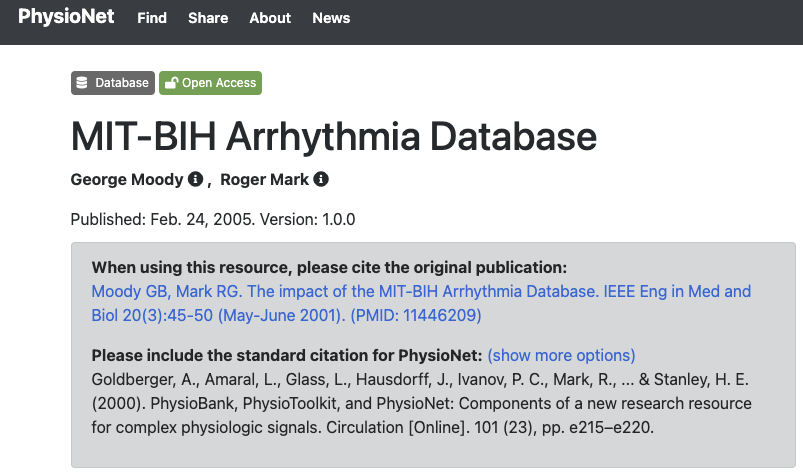
</div>
</center>





Link a la base de datos: https://www.physionet.org/content/mitdb/1.0.0/
Esta cuenta con 48 registros de ECG de 30 minutos de duración, con una frecuencia de muestreo de 360 Hz y 2 canales. Los registros están muestreados a 11 bits con un rango de 10 mV y un filtro pasa banda de 0.1-100 Hz. Los registros están etiquetados por dos cardiólogos expertos.

Cada grabación cuenta con 4 archivos:
- `.xms`: configuración para visualizar el registro en el navegador.
- `.atr`: contiene las anotaciones (en terminos de muestras) de las ondas R de cada latido.
- `.hea`: contiene información sobre el registro, como la frecuencia de muestreo, el número de canales, la duración del registro, etc.
- `.dat`: contiene las señales de ECG.

### 1.1 Cargar datos de ECG

In [ ]:
!pip install wfdb

In [ ]:
import wfdb
import os
import numpy as np
from matplotlib import pyplot as plt

subject = 200
if os.path.isdir(f"mitdb/{subject}.hea"):
    print('La data ya esta descargada.')
else:
    wfdb.dl_database('mitdb', 'mitdb', records=[str(subject)]) 

In [ ]:
# Leer señal y anotaciones
signals, fields = wfdb.rdsamp(f'mitdb/{subject}')
ann = wfdb.rdann(f'mitdb/{subject}', 'atr')
samples = ann.sample     # índices de anotaciones
symbols = ann.symbol     # símbolos (latidos)

# Construir latidos (entre anotaciones consecutivas) y reinterpolar a 256 pts
X, Y = [], []
for i in range(len(samples)-1):
    start, end = samples[i], samples[i+1]
    if end - start < 256:
        continue
    beat = np.interp(
        np.linspace(0, 1, 256),
        np.linspace(0, 1, end - start),
        signals[start:end, 0]  # canal MLII
    )
    X.append(beat)
    Y.append(0 if symbols[i] == 'N' else 1)  # 0=Normal, 1=Anómalo

X = np.array(X)     # (N, 256)
Y = np.array(Y)     # (N,)
X_normal   = X[Y==0]
X_anomalo = X[Y==1]

print(f"N latidos totales: {len(X)} | Normales: {len(X_normal)} | Anómalos: {len(X_anomalo)}")
print("Shapes:", X.shape, Y.shape)

# Normalización global z-score
mu, sd = X.mean(), X.std() + 1e-8
X = (X - mu) / sd

# Agregar dimensión canal para Conv1D: (N, 1, T)
X = X[:, None, :]
X_normal = X_normal[:, None, :]
X_anomalo = X_anomalo[:, None, :]
print("X normalizado shape:", X.shape)

En este procesamiento, la señal de ECG del registro 100 del MIT-BIH Arrhythmia Database se segmenta en latidos individuales utilizando las anotaciones provistas por el dataset, que indican la posición de cada complejo QRS. Cada latido se define como el segmento comprendido entre dos anotaciones consecutivas y se reinterpola a una longitud fija de 256 muestras, garantizando que todos los latidos tengan la misma duración para su posterior análisis. A continuación, se asigna una etiqueta binaria según el tipo de latido: aquellos marcados con el símbolo “N” se consideran normales, mientras que los demás se clasifican como anómalos. Una vez extraídos todos los segmentos, los datos se normalizan mediante una estandarización global (z-score), restando la media y dividiendo por la desviación estándar de la señal completa, con el fin de homogeneizar las amplitudes entre distintos latidos. Finalmente, se agrega una dimensión de canal para adaptar el formato de entrada al modelo convolucional 1D, quedando cada latido representado como una señal unicanal de 256 puntos lista para ser utilizada en el entrenamiento del autoencoder.


## 2. Análisis de latidos de ECG

#### Ejercicio

Antes de comenzar, es importante visualizar los latidos de ECG para comprender su morfología y variabilidad.
Cada latido fue interpolado a una longitud fija de 256 muestras, de modo que inicia en la onda R y finaliza justo antes de la siguiente onda R, garantizando una alineación temporal coherente entre todos los segmentos.

* Grafique el latido promedio normal, incluyendo barras de error que representen su desviación estándar.
* Grafique el latido promedio anómalo, también con barras de error (desviación estándar), y compare sus diferencias morfológicas con el latido normal.

HINT : Utilice la función `plt.fill_between` de Matplotlib para agregar las barras de error a sus gráficos.


In [ ]:
# <CODE>



#### Ejercicio 2
Verifique la distribución de clases en el conjunto de datos de latidos de ECG.
- Cuenta instancias por clase y grafícalas en un bar plot.
- ¿Existe desbalance? ¿Cómo impactaría en modelos supervisados?


In [ ]:
# <CODE>


#### Ejercicio 3

En este experimento de detección de anomalías con autoencoder, el modelo se entrena solo con latidos normales, aprendiendo su morfología típica. Luego, se evalúa con un conjunto mixto (normales + anómalos), donde las diferencias en el error de reconstrucción permiten identificar las anomalías.

Instrucciones:

* Divide los datos: usa el 80 % de los latidos normales para entrenamiento, y el 20 % restante junto con todos los latidos anómalos para prueba.
  Esto asegura que el modelo solo vea ejemplos normales durante el entrenamiento.
* Crea los objetos `Dataset` y `DataLoader` para ambos subconjuntos, usando un `batch_size = 64` para un entrenamiento eficiente.

Al finalizar, tendrás los conjuntos `train_loader` y `test_loader` listos para alimentar el autoencoder.


In [ ]:
# <CODE>




#### **Ejercicio 1** 

En este paso implementarás un Autoencoder Conv1D para reconstruir latidos normales y evaluar su capacidad de aprendizaje mediante la pérdida de reconstrucción (MSE).

Instrucciones:

* Define una clase `AutoEncoder` con un encoder de capas `Conv1d` (con `stride=2` y `ReLU`) que comprima la señal, y un decoder con `ConvTranspose1d` que la recupere hasta 256 muestras.
* Usa `MSELoss()` como función de pérdida y Adam como optimizador (`lr=1e-3`, `weight_decay=1e-5`).
* Entrena el modelo 30–50 épocas utilizando solo los latidos normales (`train_loader`).
* Registra la pérdida promedio por época y grafica su evolución con `matplotlib`.
* Realiza inferencia en un latido normal y compara la señal original con la reconstruida.

El objetivo es observar cómo el modelo aprende a reconstruir la forma típica del ECG normal: una pérdida decreciente indica una mejor representación de la morfología normal.


In [ ]:

# <CODE>



#### **Ejercicio 2** 
Ya se compararon los latidos normales, ahora es momento de evaluar el desempeño del autoencoder en la detección de anomalías.
Instrucciones:
* Realiza inferencia con el autoencoder en el conjunto X_anomalo y grafica el latido original junto con su reconstrucción.
* Calcula el error de reconstrucción (MSE) para cada latido en el conjunto de prueba (X_test).
* Grafica la distribución de los errores de reconstrucción para latidos normales y anómalos utilizando un histograma.
* Analiza si existe una separación clara entre los errores de ambos tipos de latidos, lo que indicaría la efectividad del autoencoder para detectar anomalías.


In [ ]:
# <CODE>
